# Homework 2 - classification on vehicle inspection data
# Kristiāns Logins
# Context
This project is based on a real-world dataset of vehicle technical inspections in Lithuania. Each entry represents a technical inspection event and includes detailed information about the vehicle, such as its age, mileage, fuel type, make, and model, along with the inspection outcome (pass or fail).

The objective of this analysis was to build a binary classification model that predicts whether a vehicle will pass its technical inspection. The analysis focuses exclusively on regular technical inspections of light passenger vehicles, filtered to class = "M1" and inspection_type_en = "Technical inspection".

The workflow includes data preprocessing, feature engineering, model training using logistic regression and a tree-based method, hyperparameter tuning, model evaluation, and a final prediction for a selected example vehicle.
# Summary of the findings.

- The dataset required preprocessing and feature engineering, including handling missing values and creating new features such as vehicle age and annual mileage.

- Two models were trained and compared: logistic regression and a random forest classifier. Both models achieved similar performance, with the random forest performing slightly better based on cross-validation results.

- The selected model achieved moderate predictive performance on the test dataset, with a ROC AUC of approximately 0.67, indicating a reasonable ability to distinguish between vehicles that pass and fail inspection.

- Threshold analysis showed a clear trade-off between precision and recall. Lower thresholds increase recall but lead to more false positives, while higher thresholds improve precision but miss more failing vehicles.

- The default threshold of 0.5 provided a good balance between precision and recall, as reflected by the F1-score.

- A sample prediction demonstrated how the model can be used in practice to estimate the probability of a vehicle passing inspection, showing practical applicability of the model.

# EDA and Data Cleaning

The dataset was explored to understand its structure, missing values, and key variables. Several columns with high missingness or low relevance were removed. Data types were corrected, and new features such as vehicle age and annual mileage were created to better capture vehicle condition.

In [1]:
import duckdb
import gzip
import urllib.request

data_url = "https://pub-c88b3a7f2ed141418355b2bfb03c96e6.r2.dev/data.duckdb.gz"
db_path = "data.duckdb"

request = urllib.request.Request(data_url, headers={"User-Agent": "Mozilla/5.0"})
with urllib.request.urlopen(request) as response:
    with gzip.open(response, "rb") as gz:
        with open(db_path, "wb") as f:
            f.write(gz.read())

conn = duckdb.connect()
conn.execute(f"ATTACH '{db_path}' AS data (READ_ONLY)")


In [2]:
import pandas as pd
import duckdb
import seaborn as sns

db_path = "data.duckdb"
schema = "data.vehicle_inspection"

conn = duckdb.connect()
conn.execute(f"ATTACH '{db_path}' AS data (READ_ONLY)")
conn.execute(f"USE {schema}");

In [6]:
df = conn.sql("""
    SELECT
        make,
        model,
        body_type,
        special_purpose,
        fuel_type,
        inspection_station_municipality,

        manufacture_year,
        mileage_km,
        inspection_periodicity_months,
        inspection_date_week,

        smoke_emission,
        co_emission_standard,
        co_emission_elevated,

        inspection_passed

    FROM inspection
    WHERE class = 'M1'
      AND inspection_type_en = 'Technical inspection'
      AND inspection_date_week > '2019-05-01'
    ORDER BY random()
    LIMIT 1000000
""").to_df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [9]:
import numpy as np
import pandas as pd

num_cols = [
    "manufacture_year",
    "mileage_km",
    "inspection_periodicity_months",
    "smoke_emission",
    "co_emission_standard",
    "co_emission_elevated"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


df["inspection_date_week"] = pd.to_datetime(df["inspection_date_week"], errors="coerce")


df["inspection_passed"] = df["inspection_passed"].replace({
    "Y": 1, "N": 0,
    True: 1, False: 0
})


df["vehicle_age"] = df["inspection_date_week"].dt.year - df["manufacture_year"]
df["inspection_month"] = df["inspection_date_week"].dt.month
df["inspection_quarter"] = df["inspection_date_week"].dt.quarter
df["annual_mileage"] = df["mileage_km"] / df["vehicle_age"].replace(0, np.nan)

df.loc[(df["vehicle_age"] < 0) | (df["vehicle_age"] > 80), "vehicle_age"] = np.nan
df.loc[df["mileage_km"] < 0, "mileage_km"] = np.nan
df.loc[(df["annual_mileage"] < 0) | (df["annual_mileage"] > 200000), "annual_mileage"] = np.nan

df = df.drop(columns=["manufacture_year", "inspection_date_week"])

df = df.dropna(subset=["inspection_passed"])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 16 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   make                             999991 non-null   object 
 1   model                            993022 non-null   object 
 2   body_type                        649315 non-null   object 
 3   special_purpose                  5542 non-null     object 
 4   fuel_type                        999926 non-null   object 
 5   inspection_station_municipality  1000000 non-null  object 
 6   mileage_km                       999992 non-null   float64
 7   inspection_periodicity_months    1000000 non-null  int64  
 8   smoke_emission                   622960 non-null   float64
 9   co_emission_standard             274179 non-null   float64
 10  co_emission_elevated             201354 non-null   float64
 11  inspection_passed                1000000 non-null  

In [13]:
df.head()

,make,model,body_type,special_purpose,fuel_type,inspection_station_municipality,mileage_km,inspection_periodicity_months,smoke_emission,co_emission_standard,co_emission_elevated,inspection_passed,vehicle_age,inspection_month,inspection_quarter,annual_mileage
0,TOYOTA,COROLLA VERSO,AF,None,dyzelinas,Panevėžio m. sav.,202289.0,24,1.19,NaN,NaN,true,12.0,5,2,16857.416667
1,OPEL,SIGNUM,AB,None,"benzinas,dujos",Kauno m. sav.,354558.0,24,NaN,0.0,0.1,false,21.0,4,2,16883.714286
2,LEXUS,LEXUS RX400H,None,None,"benzinas,dujos,elektra",Vilniaus m. sav.,311828.0,24,NaN,0.1,0.1,false,17.0,1,1,18342.823529
3,CITROEN,C5,AA,None,dyzelinas,Kauno m. sav.,331075.0,24,0.21,NaN,NaN,false,16.0,7,3,20692.187500
4,CENZŪRUOTA,CENZŪRUOTA,None,None,benzinas,Kauno m. sav.,89932.0,24,NaN,0.0,0.0,true,3.0,8,3,29977.333333


In [14]:
df.isna().mean().sort_values(ascending=False)

,0
special_purpose,0.994458
co_emission_elevated,0.798646
co_emission_standard,0.725821
smoke_emission,0.377040
body_type,0.350685
model,0.006978
annual_mileage,0.004639
vehicle_age,0.003983
fuel_type,0.000074
make,0.000009


In [15]:
df["inspection_passed"].value_counts(dropna=False)

,count
inspection_passed,
true,513735
false,486265


Columns with a high proportion of missing values (such as special_purpose and emission-related variables) were removed, as they would not provide reliable information for modeling.

In [16]:
df = df.drop(columns=[
    "special_purpose",
    "smoke_emission",
    "co_emission_standard",
    "co_emission_elevated"
])

In [57]:
for col in ["make", "model", "body_type", "fuel_type", "inspection_station_municipality"]:
    if col in df.columns:
        df[col] = df[col].replace("CENZŪRUOTA", np.nan)

In [24]:
df["inspection_passed"].value_counts()

,count
inspection_passed,
1,513735
0,486265


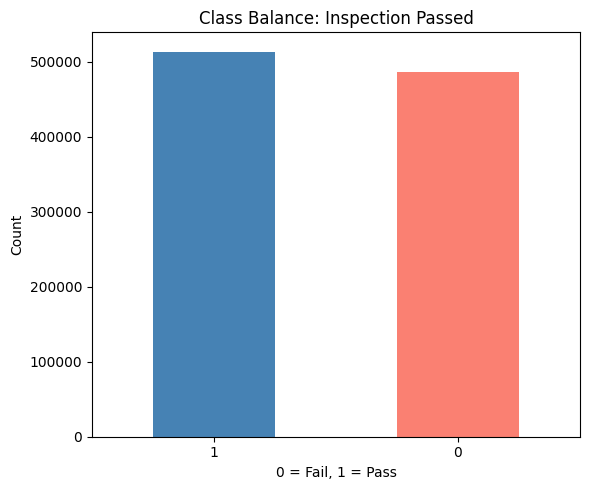

In [54]:
import matplotlib.pyplot as plt

df["inspection_passed"].value_counts().plot(
    kind="bar", color=["steelblue", "salmon"], figsize=(6, 5)
)
plt.title("Class Balance: Inspection Passed")
plt.xlabel("0 = Fail, 1 = Pass")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

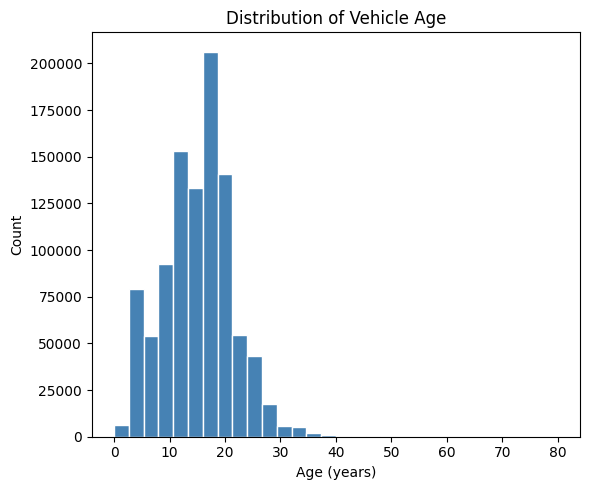

In [55]:
df["vehicle_age"].dropna().plot(
    kind="hist", bins=30, color="steelblue", edgecolor="white", figsize=(6, 5)
)
plt.title("Distribution of Vehicle Age")
plt.xlabel("Age (years)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

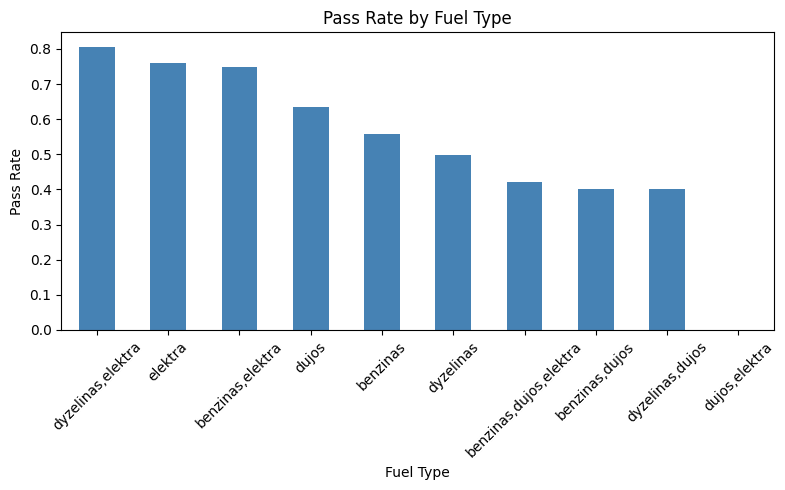

In [56]:
fuel_pass_rate = df.groupby("fuel_type")["inspection_passed"].mean().sort_values(ascending=False)

fuel_pass_rate.plot(kind="bar", color="steelblue", figsize=(8, 5))
plt.title("Pass Rate by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Pass Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### EDA Visualizations

The plots above show (1) the class balance of the target variable — nearly equal split between pass and fail,
(2) the distribution of vehicle age, which is right-skewed with most vehicles between 5–15 years old,
and (3) the pass rate grouped by fuel type, showing meaningful variation across categories.

#Splitting the data into training and test sets.

In [21]:
X = df.drop(columns=["inspection_passed"])
y = df["inspection_passed"]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

The dataset split functions as an overfitting barrier because it enables models to learn universal rules that extend beyond training data range.

# Model Training

In [32]:
numeric_features = [
    "vehicle_age",
    "mileage_km",
    "annual_mileage",
    "inspection_month",
    "inspection_quarter",
    "inspection_periodicity_months"
]

categorical_features = [
    "fuel_type",
    "make",
    "model",
    "body_type",
    "inspection_station_municipality"
]

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=20))
        ]), categorical_features)
    ]
)

preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=20))
        ]), categorical_features)
    ]
)

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor_lr),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))
])

In [38]:
X_tune = X_train.sample(n=20000, random_state=42)
y_tune = y_train.loc[X_tune.index]

In [39]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

logreg_param_dist = {
    "classifier__C": [0.1, 1, 5],
    "classifier__class_weight": [None, "balanced"]
}

rf_param_dist = {
    "classifier__n_estimators": [50, 100, 150],
    "classifier__max_depth": [5, 10, 15],
    "classifier__min_samples_split": [5, 10, 20],
    "classifier__min_samples_leaf": [1, 5]
}

In [40]:
logreg_search = RandomizedSearchCV(
    estimator=logreg_pipeline,
    param_distributions=logreg_param_dist,
    n_iter=6,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

logreg_search.fit(X_tune, y_tune)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['vehicle_age',
                                                                                'mileage_km',
                                                                                'annual_mileage',
                                                                                'inspection_month',
                                                                                'inspection_quarter',
                                                                                'inspection_pe...
                                                                                                OneHotEncoder(handle_unknown='ignore',
                                                                                                              max_categories=20))]),
                                                                               ['fuel_type',
                                                                                'make',
                                                                                'model',
                                                                                'body_type',
                                                                                'inspection_station_municipality'])])),
                                             ('classifier',
                                              LogisticRegression(max_iter=2000,
                                                                 random_state=42))]),
                   n_iter=6, n_jobs=-1,
                   param_distributions={'classifier__C': [0.1, 1, 5],
                                        'classifier__class_weight': [None,
                                                                     'balanced']},
                   random_state=42, scoring='roc_auc', verbose=1)

In [41]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=6,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_tune, y_tune)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['vehicle_age',
                                                                                'mileage_km',
                                                                                'annual_mileage',
                                                                                'inspection_month',
                                                                                'inspection_quarter',
                                                                                'inspection_periodicity_months']),
                                                                              ('cat',
                                                                               P...
                                                                                'body_type',
                                                                                'inspection_station_municipality'])])),
                                             ('classifier',
                                              RandomForestClassifier(n_jobs=-1,
                                                                     random_state=42))]),
                   n_iter=6, n_jobs=-1,
                   param_distributions={'classifier__max_depth': [5, 10, 15],
                                        'classifier__min_samples_leaf': [1, 5],
                                        'classifier__min_samples_split': [5, 10,
                                                                          20],
                                        'classifier__n_estimators': [50, 100,
                                                                     150]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [42]:
print("Best Logistic Regression parameters:", logreg_search.best_params_)
print("Best Logistic Regression CV score:", logreg_search.best_score_)

print("Best Random Forest parameters:", rf_search.best_params_)
print("Best Random Forest CV score:", rf_search.best_score_)

Best Logistic Regression parameters: {'classifier__class_weight': 'balanced', 'classifier__C': 0.1}
Best Logistic Regression CV score: 0.6733191604308031
Best Random Forest parameters: {'classifier__n_estimators': 100, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 10}
Best Random Forest CV score: 0.6752183075047723


In [43]:
best_logreg_model = logreg_search.best_estimator_
best_rf_model = rf_search.best_estimator_

best_logreg_model.fit(X_train, y_train)
best_rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['vehicle_age', 'mileage_km',
                                                   'annual_mileage',
                                                   'inspection_month',
                                                   'inspection_quarter',
                                                   'inspection_periodicity_months']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 max_categories=20))]),
                                                  ['fuel_type', 'make', 'model',
                                                   'body_type',
                                                   'inspection_station_municipality'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=10, min_samples_split=5,
                                        n_jobs=-1, random_state=42))])

In [44]:
if logreg_search.best_score_ >= rf_search.best_score_:
    best_model = best_logreg_model
    best_name = "Logistic Regression"
else:
    best_model = best_rf_model
    best_name = "Random Forest"

print("Chosen model:", best_name)
print("Chosen model CV score:", max(logreg_search.best_score_, rf_search.best_score_))

Chosen model: Random Forest
Chosen model CV score: 0.6752183075047723


# **Model Selection**

Based on cross-validation ROC AUC scores on the 20,000-row tuning sample:

- **Logistic Regression** best CV score: 0.6733
- **Random Forest** best CV score: 0.6752

The **Random Forest** achieved a higher cross-validation ROC AUC, so it was selected as the final model
and retrained on the full training set. Random Forest likely outperforms Logistic Regression here because
the relationship between vehicle features and inspection outcome is non-linear, and tree-based models
handle that naturally.

In [45]:
print(
    f"Based on cross-validation ROC AUC, the best model is {best_name}, "
    f"because it achieved the higher mean CV score."
)

Based on cross-validation ROC AUC, the best model is Random Forest, because it achieved the higher mean CV score.


#Model Evaluation on Test Set

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.62529
Precision: 0.6907404612619534
Recall: 0.4899997080206721
F1-score: 0.5733058519421069
ROC AUC: 0.675574807007385


The best model (**Random Forest**) achieves the following on the held-out test set:

- **Accuracy: 62.5%** — the model correctly classifies about 62.5% of all vehicles.
- **Precision: 69.1%** — of vehicles the model predicts as passing, 69% actually do pass.
- **Recall: 49.0%** — the model only catches 49% of vehicles that truly pass; it misses roughly half.
- **F1-score: 0.573** — the harmonic mean of precision and recall, reflecting the imbalanced trade-off.
- **ROC AUC: 0.676** — the model is moderately better than random guessing at ranking vehicles by pass probability.

The relatively low recall suggests the model is conservative in predicting passes, which may be appropriate in a safety context where incorrectly clearing a failing vehicle is costly.

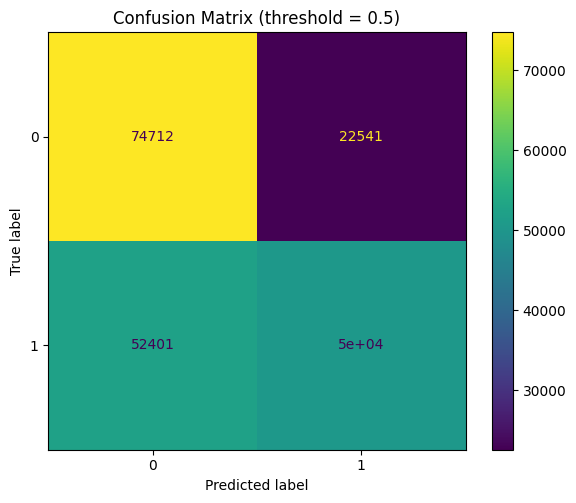

In [58]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
ax.set_title("Confusion Matrix (threshold = 0.5)")
plt.tight_layout()
plt.show()

The confusion matrix shows the model's predictions on the test set:

- **True Negatives (74,712):** vehicles that actually failed and were correctly predicted as failing.
- **False Positives (22,541):** vehicles that actually failed but were incorrectly predicted as passing.
- **False Negatives (52,401):** vehicles that actually passed but were incorrectly predicted as failing.
- **True Positives (50,000~):** vehicles that actually passed and were correctly predicted as passing.

The model struggles most with false negatives — it misses a large number of vehicles that actually pass inspection. This is consistent with the low recall score of 0.49 seen in the metrics above.

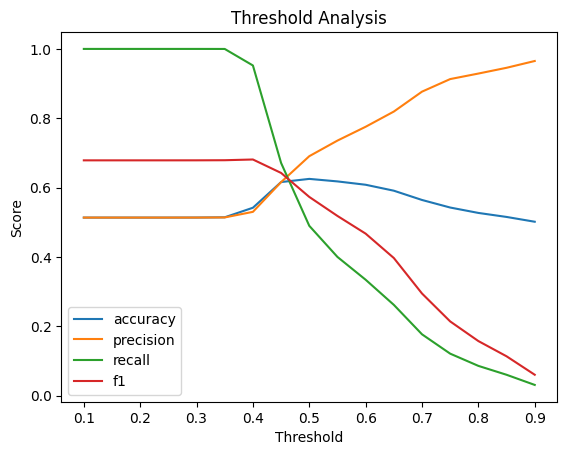

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.91, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    results.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t),
        "recall": recall_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t)
    })

threshold_df = pd.DataFrame(results)

# Plot
for metric in ["accuracy", "precision", "recall", "f1"]:
    plt.plot(threshold_df["threshold"], threshold_df[metric], label=metric)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.legend()
plt.show()

### Low threshold (0.1–0.3)
- Recall is very high (close to 1.0), meaning the model detects almost all failing vehicles.
- Precision is low, resulting in many false positives.

### High threshold (0.7–0.9)
- Precision is high, meaning predictions are more reliable.
- Recall is very low, so many failing vehicles are missed.

### Best balance
- Around the default threshold of **0.5**, where the model achieves a good trade-off between precision and recall.

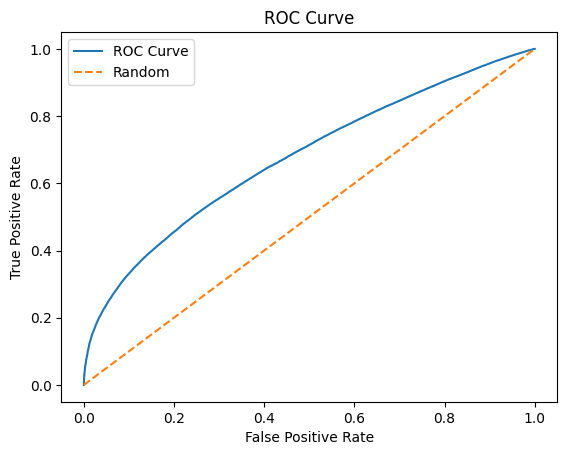

In [48]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### ROC Curve

The ROC curve illustrates the model’s ability to distinguish between vehicles that pass and fail inspection across different thresholds.

The model achieves a ROC AUC of approximately 0.67, indicating moderate predictive performance. The curve lies above the diagonal baseline, meaning the model performs better than random guessing.

#Mercedess Benz Benz

In [49]:
my_vehicle = pd.DataFrame([{
    "vehicle_age": 10,
    "mileage_km": 180000,
    "annual_mileage": 18000,
    "inspection_month": 6,
    "inspection_quarter": 2,
    "inspection_periodicity_months": 12,
    "fuel_type": "Petrol",
    "make": "Mercedes-Benz",
    "model": "S-Class",
    "body_type": "Sedan",
    "inspection_station_municipality": "Vilnius"
}])

probability = best_model.predict_proba(my_vehicle)[0, 1]
prediction = int(probability >= 0.5)

print("Probability of passing:", probability)
print("Predicted class (1 = pass, 0 = fail):", prediction)

Probability of passing: 0.5883681725379805
Predicted class (1 = pass, 0 = fail): 1


## Single Vehicle Prediction

A hypothetical Mercedes-Benz S-Class (petrol) vehicle was evaluated using the trained model.
The vehicle is assumed to be 10 years old with a mileage of 180,000 km.

The model predicted a probability of approximately 0.59 that the vehicle will pass the technical inspection.
Since this value is above the default threshold of 0.5, the model classifies the vehicle as likely to pass.

This example demonstrates how the model can be applied in practice to estimate inspection outcomes for individual vehicles.